# Premarket Predictive Power Analysis

**Question:** Does premarket (PRE session) price action predict what happens during regular trading hours (RTH) for SPY and QQQ?

**Methodology:**
- `premarket_return` = (last PRE bar close − prev RTH close) / prev RTH close
- `rth_return` = (RTH close − RTH open) / RTH open  
- `gap_pct` = (RTH open − PRE close) / PRE close

> **Data:** Run `python fetch_bars.py` first to populate `data/spy_daily.csv` and `data/qqq_daily.csv`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('tab10')

DATA_DIR = Path('data')
SYMBOLS = ['SPY', 'QQQ']

## 1. Load & Validate Data

In [2]:
def load_symbol(symbol: str) -> pd.DataFrame:
    path = DATA_DIR / f'{symbol.lower()}_daily.csv'
    if not path.exists():
        raise FileNotFoundError(
            f'{path} not found. Run `python fetch_bars.py` first.'
        )
    df = pd.read_csv(path, parse_dates=['date'])
    df['date'] = pd.to_datetime(df['date']).dt.date
    df = df.dropna(subset=['premarket_return', 'rth_return'])
    df = df.sort_values('date').reset_index(drop=True)
    return df

data = {sym: load_symbol(sym) for sym in SYMBOLS}

for sym, df in data.items():
    print(f'{sym}: {len(df)} trading days  |  {df["date"].min()} → {df["date"].max()}')
    print(df[['premarket_return', 'rth_return', 'gap_pct']].describe().applymap(lambda x: f'{x*100:.4f}%'))
    print()

SPY: 1121 trading days  |  2022-01-04 → 2026-06-24
      premarket_return    rth_return       gap_pct
count     112100.0000%  112100.0000%  112100.0000%
mean           0.0186%       0.0254%       0.0008%
std            0.6761%       0.9301%       0.0102%
min           -4.0814%      -4.8852%      -0.2251%
25%           -0.2705%      -0.4308%      -0.0022%
50%            0.0487%       0.0533%       0.0000%
75%            0.3477%       0.4999%       0.0033%
max            3.7206%      11.1242%       0.0577%

QQQ: 1121 trading days  |  2022-01-04 → 2026-06-24
      premarket_return    rth_return       gap_pct
count     112100.0000%  112100.0000%  112100.0000%
mean           0.0329%       0.0303%      -0.0008%
std            0.9013%       1.2274%       0.0175%
min           -6.4407%      -5.0438%      -0.1235%
25%           -0.3997%      -0.6154%      -0.0068%
50%            0.0567%       0.0955%       0.0000%
75%            0.4722%       0.7066%       0.0061%
max            4.8952%      12

## 2. Descriptive Distributions

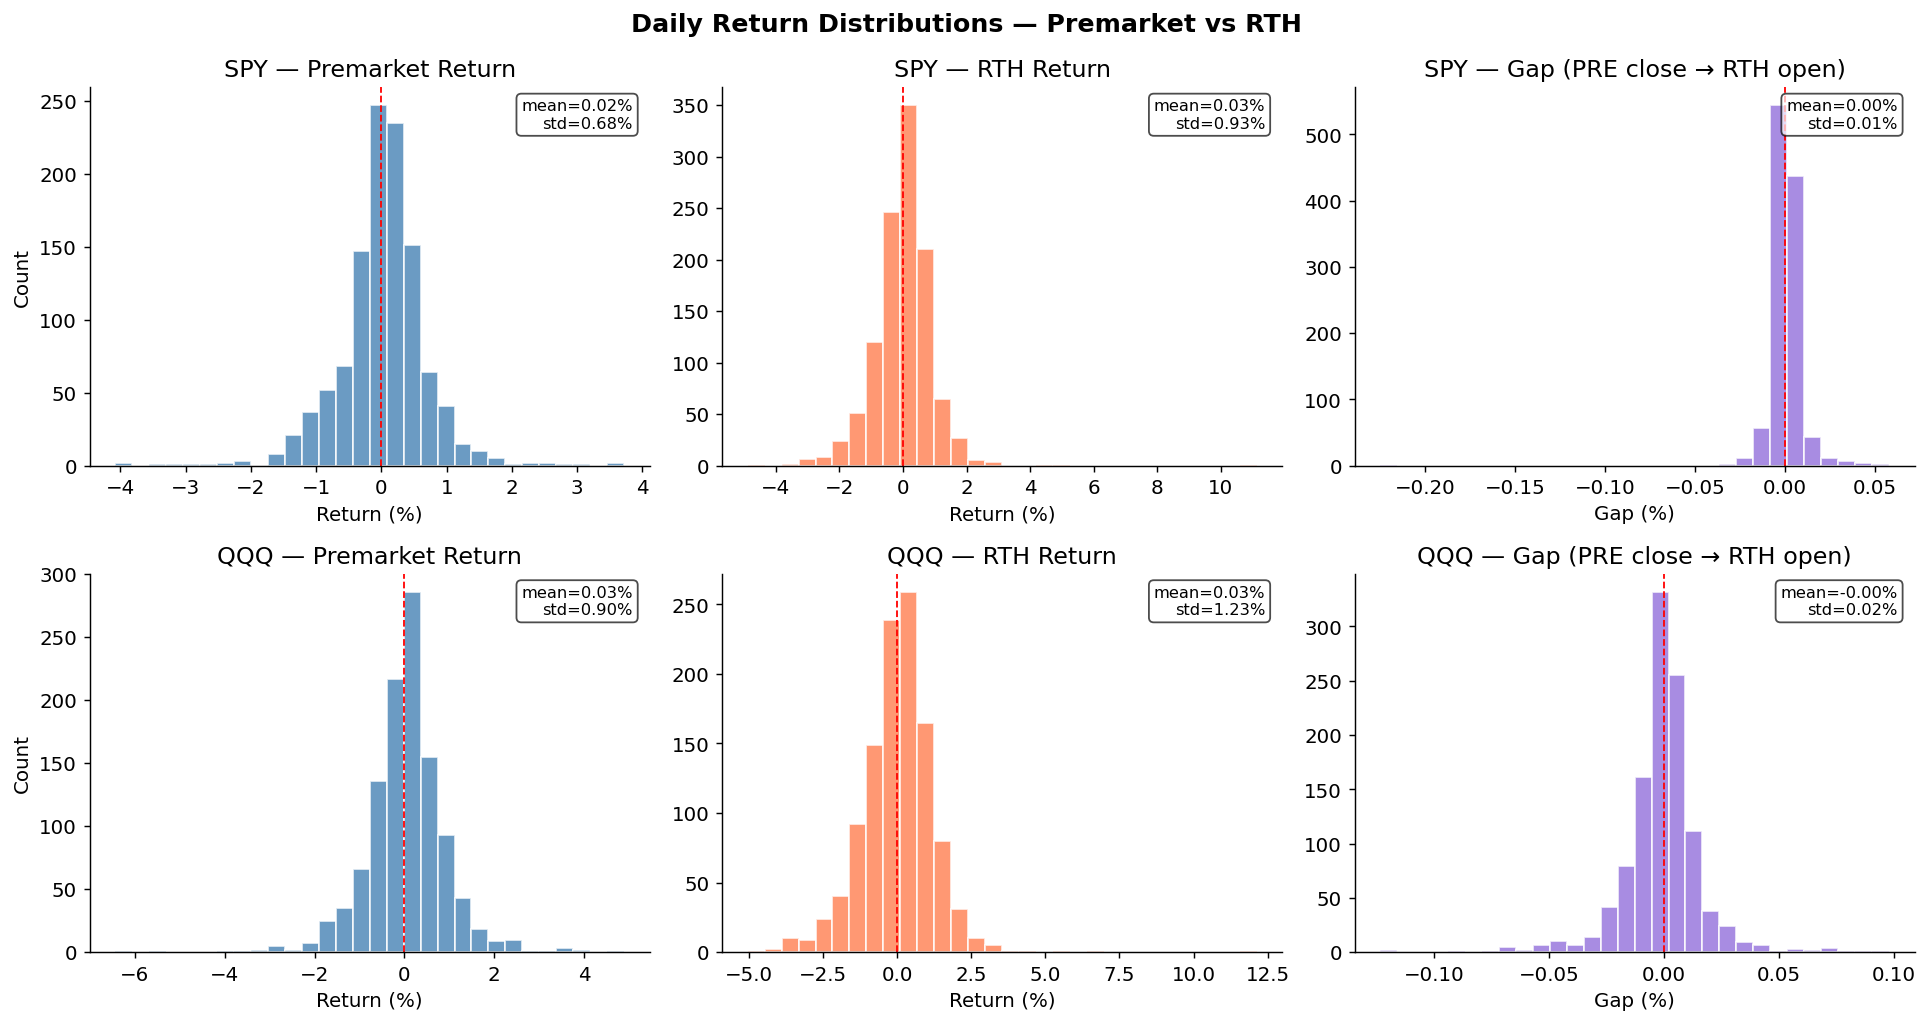

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Daily Return Distributions — Premarket vs RTH', fontsize=14, fontweight='bold')

for row, sym in enumerate(SYMBOLS):
    df = data[sym]

    ax = axes[row, 0]
    ax.hist(df['premarket_return'] * 100, bins=30, edgecolor='white', color='steelblue', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'{sym} — Premarket Return')
    ax.set_xlabel('Return (%)')
    ax.set_ylabel('Count')
    stats_text = (f'mean={df["premarket_return"].mean()*100:.2f}%\n'
                  f'std={df["premarket_return"].std()*100:.2f}%')
    ax.text(0.97, 0.97, stats_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    ax = axes[row, 1]
    ax.hist(df['rth_return'] * 100, bins=30, edgecolor='white', color='coral', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'{sym} — RTH Return')
    ax.set_xlabel('Return (%)')
    stats_text = (f'mean={df["rth_return"].mean()*100:.2f}%\n'
                  f'std={df["rth_return"].std()*100:.2f}%')
    ax.text(0.97, 0.97, stats_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    ax = axes[row, 2]
    ax.hist(df['gap_pct'] * 100, bins=30, edgecolor='white', color='mediumpurple', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'{sym} — Gap (PRE close → RTH open)')
    ax.set_xlabel('Gap (%)')
    stats_text = (f'mean={df["gap_pct"].mean()*100:.2f}%\n'
                  f'std={df["gap_pct"].std()*100:.2f}%')
    ax.text(0.97, 0.97, stats_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

## 3. Correlation Analysis

In [4]:
print('=== Correlation: Premarket Return → RTH Return ===\n')

corr_results = {}
for sym in SYMBOLS:
    df = data[sym]
    x = df['premarket_return']
    y = df['rth_return']

    pearson_r, pearson_p = stats.pearsonr(x, y)
    spearman_r, spearman_p = stats.spearmanr(x, y)

    corr_results[sym] = {
        'pearson_r': pearson_r,
        'pearson_p': pearson_p,
        'spearman_r': spearman_r,
        'spearman_p': spearman_p,
    }

    sig_pearson = '***' if pearson_p < 0.001 else ('**' if pearson_p < 0.01 else ('*' if pearson_p < 0.05 else 'n.s.'))
    sig_spearman = '***' if spearman_p < 0.001 else ('**' if spearman_p < 0.01 else ('*' if spearman_p < 0.05 else 'n.s.'))

    print(f'{sym} (n={len(df)})')
    print(f'  Pearson  r = {pearson_r:+.4f}   p = {pearson_p:.4f}  {sig_pearson}')
    print(f'  Spearman ρ = {spearman_r:+.4f}   p = {spearman_p:.4f}  {sig_spearman}')
    print()

print('Significance: * p<0.05  ** p<0.01  *** p<0.001  n.s. = not significant')

=== Correlation: Premarket Return → RTH Return ===

SPY (n=1121)
  Pearson  r = -0.0679   p = 0.0231  *
  Spearman ρ = -0.0108   p = 0.7172  n.s.

QQQ (n=1121)
  Pearson  r = -0.0622   p = 0.0372  *
  Spearman ρ = +0.0086   p = 0.7739  n.s.

Significance: * p<0.05  ** p<0.01  *** p<0.001  n.s. = not significant


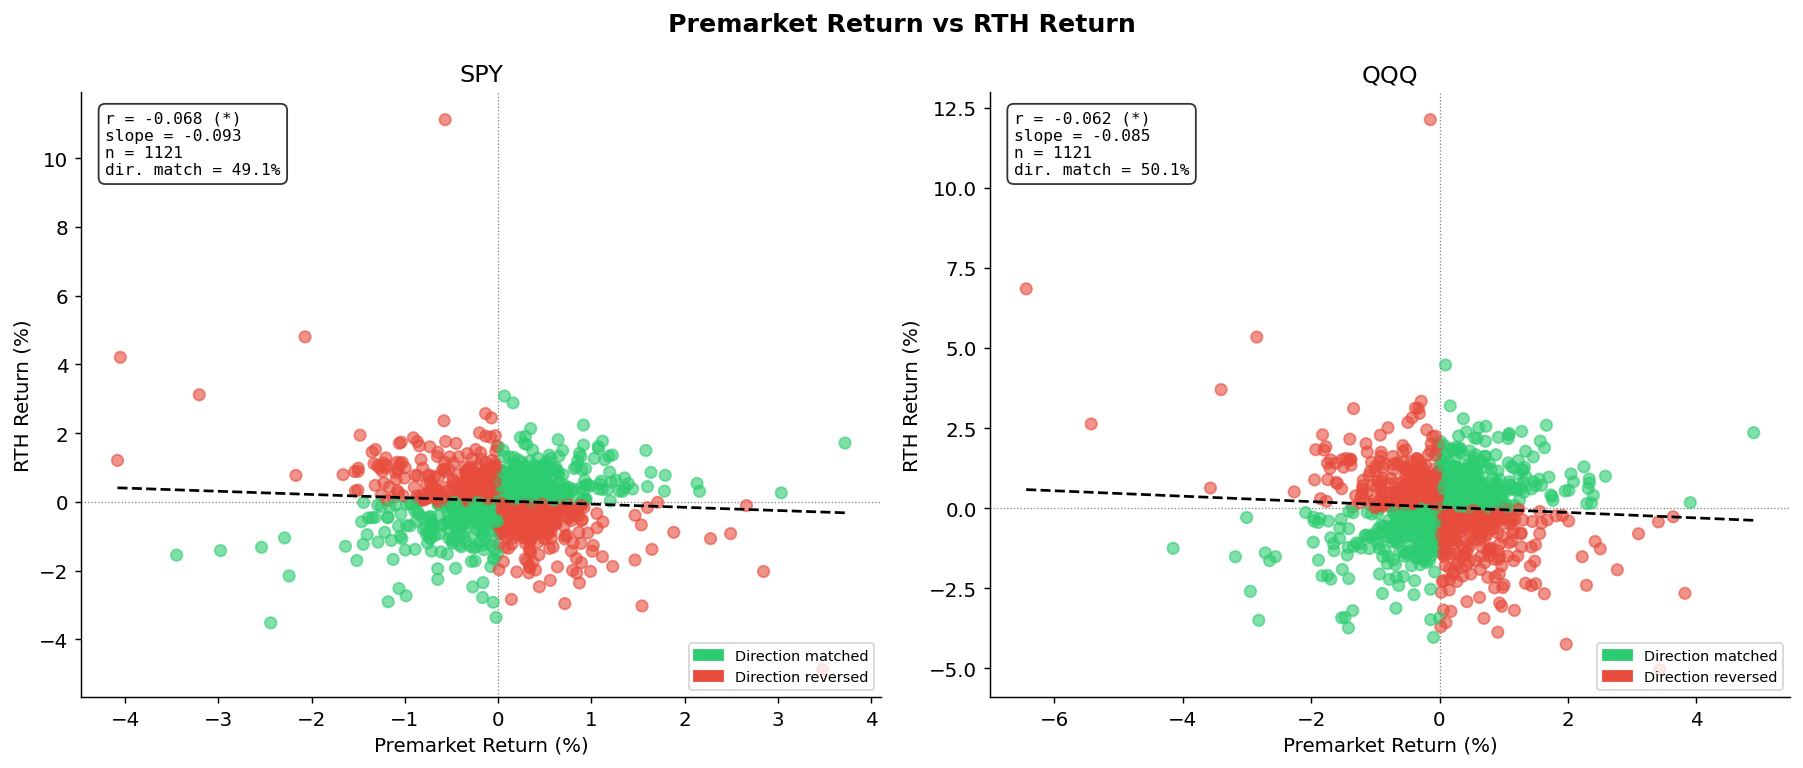

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Premarket Return vs RTH Return', fontsize=14, fontweight='bold')

for ax, sym in zip(axes, SYMBOLS):
    df = data[sym]
    x = df['premarket_return'] * 100
    y = df['rth_return'] * 100

    # Colour points by whether premarket and RTH direction matched
    colors = ['#2ecc71' if (xi > 0) == (yi > 0) else '#e74c3c'
              for xi, yi in zip(x, y)]
    ax.scatter(x, y, c=colors, alpha=0.6, s=40, zorder=3)

    # OLS trend line
    m, b, r_val, p_val, _ = stats.linregress(x, y)
    x_range = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_range, m * x_range + b, 'k--', linewidth=1.5, zorder=4)

    ax.axhline(0, color='grey', linewidth=0.7, linestyle=':')
    ax.axvline(0, color='grey', linewidth=0.7, linestyle=':')

    cr = corr_results[sym]
    sig = '***' if cr['pearson_p'] < 0.001 else ('**' if cr['pearson_p'] < 0.01 else ('*' if cr['pearson_p'] < 0.05 else 'n.s.'))
    match_pct = sum((xi > 0) == (yi > 0) for xi, yi in zip(x, y)) / len(x) * 100

    info = (f"r = {cr['pearson_r']:+.3f} ({sig})\n"
            f"slope = {m:.3f}\n"
            f"n = {len(df)}\n"
            f"dir. match = {match_pct:.1f}%")
    ax.text(0.03, 0.97, info, transform=ax.transAxes,
            ha='left', va='top', fontsize=9, fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

    ax.set_xlabel('Premarket Return (%)')
    ax.set_ylabel('RTH Return (%)')
    ax.set_title(sym)

    # Legend
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color='#2ecc71', label='Direction matched'),
        Patch(color='#e74c3c', label='Direction reversed'),
    ], loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

## 4. OLS Regression

In [6]:
print('=== OLS Regression: rth_return ~ premarket_return ===\n')

for sym in SYMBOLS:
    df = data[sym]
    X = sm.add_constant(df['premarket_return'])
    y = df['rth_return']
    model = sm.OLS(y, X).fit()

    print(f'{sym}')
    print(f'  R²            = {model.rsquared:.4f}  ({model.rsquared*100:.2f}% of RTH variance explained)')
    print(f'  Intercept     = {model.params["const"]*100:.4f}%  (p={model.pvalues["const"]:.4f})')
    print(f'  Slope         = {model.params["premarket_return"]:.4f}  (p={model.pvalues["premarket_return"]:.4f})')
    print(f'  F-stat p-val  = {model.f_pvalue:.4f}')
    print()

print('Interpretation: slope tells you how many basis points RTH moves per 1bp of premarket move.')

=== OLS Regression: rth_return ~ premarket_return ===

SPY
  R²            = 0.0046  (0.46% of RTH variance explained)
  Intercept     = 0.0272%  (p=0.3273)
  Slope         = -0.0934  (p=0.0231)
  F-stat p-val  = 0.0231

QQQ
  R²            = 0.0039  (0.39% of RTH variance explained)
  Intercept     = 0.0331%  (p=0.3662)
  Slope         = -0.0848  (p=0.0372)
  F-stat p-val  = 0.0372

Interpretation: slope tells you how many basis points RTH moves per 1bp of premarket move.


## 5. Directional Accuracy

In [7]:
print('=== Directional Accuracy ===\n')
print('Does knowing premarket direction (up/down) predict RTH direction?\n')

dir_results = {}

for sym in SYMBOLS:
    df = data[sym]
    pm = df['premarket_return']
    rth = df['rth_return']

    match = ((pm > 0) == (rth > 0)).mean()
    n = len(df)

    # Binomial test: is the accuracy significantly different from 50%?
    k = int(round(match * n))
    binom_result = stats.binomtest(k, n, p=0.5, alternative='two-sided')

    # Break down by premarket direction
    pre_up_mask = pm > 0
    pre_dn_mask = pm <= 0

    acc_when_pm_up = ((rth > 0)[pre_up_mask]).mean()
    acc_when_pm_dn = ((rth <= 0)[pre_dn_mask]).mean()

    dir_results[sym] = {
        'overall': match,
        'binom_p': binom_result.pvalue,
        'when_pm_up': acc_when_pm_up,
        'when_pm_dn': acc_when_pm_dn,
    }

    sig = ('***' if binom_result.pvalue < 0.001 else
           ('**' if binom_result.pvalue < 0.01 else
            ('*' if binom_result.pvalue < 0.05 else 'n.s.')))

    print(f'{sym} (n={n})')
    print(f'  Overall directional accuracy : {match*100:.1f}%  (binomial p={binom_result.pvalue:.4f} {sig})')
    print(f'  When premarket UP  → RTH UP  : {acc_when_pm_up*100:.1f}%  (n={pre_up_mask.sum()})')
    print(f'  When premarket DN  → RTH DN  : {acc_when_pm_dn*100:.1f}%  (n={pre_dn_mask.sum()})')
    print()

=== Directional Accuracy ===

Does knowing premarket direction (up/down) predict RTH direction?

SPY (n=1121)
  Overall directional accuracy : 49.1%  (binomial p=0.5503 n.s.)
  When premarket UP  → RTH UP  : 52.4%  (n=617)
  When premarket DN  → RTH DN  : 45.0%  (n=504)

QQQ (n=1121)
  Overall directional accuracy : 50.1%  (binomial p=0.9524 n.s.)
  When premarket UP  → RTH UP  : 53.5%  (n=609)
  When premarket DN  → RTH DN  : 46.1%  (n=512)



## 6. Conditional Analysis — Quartile Bins

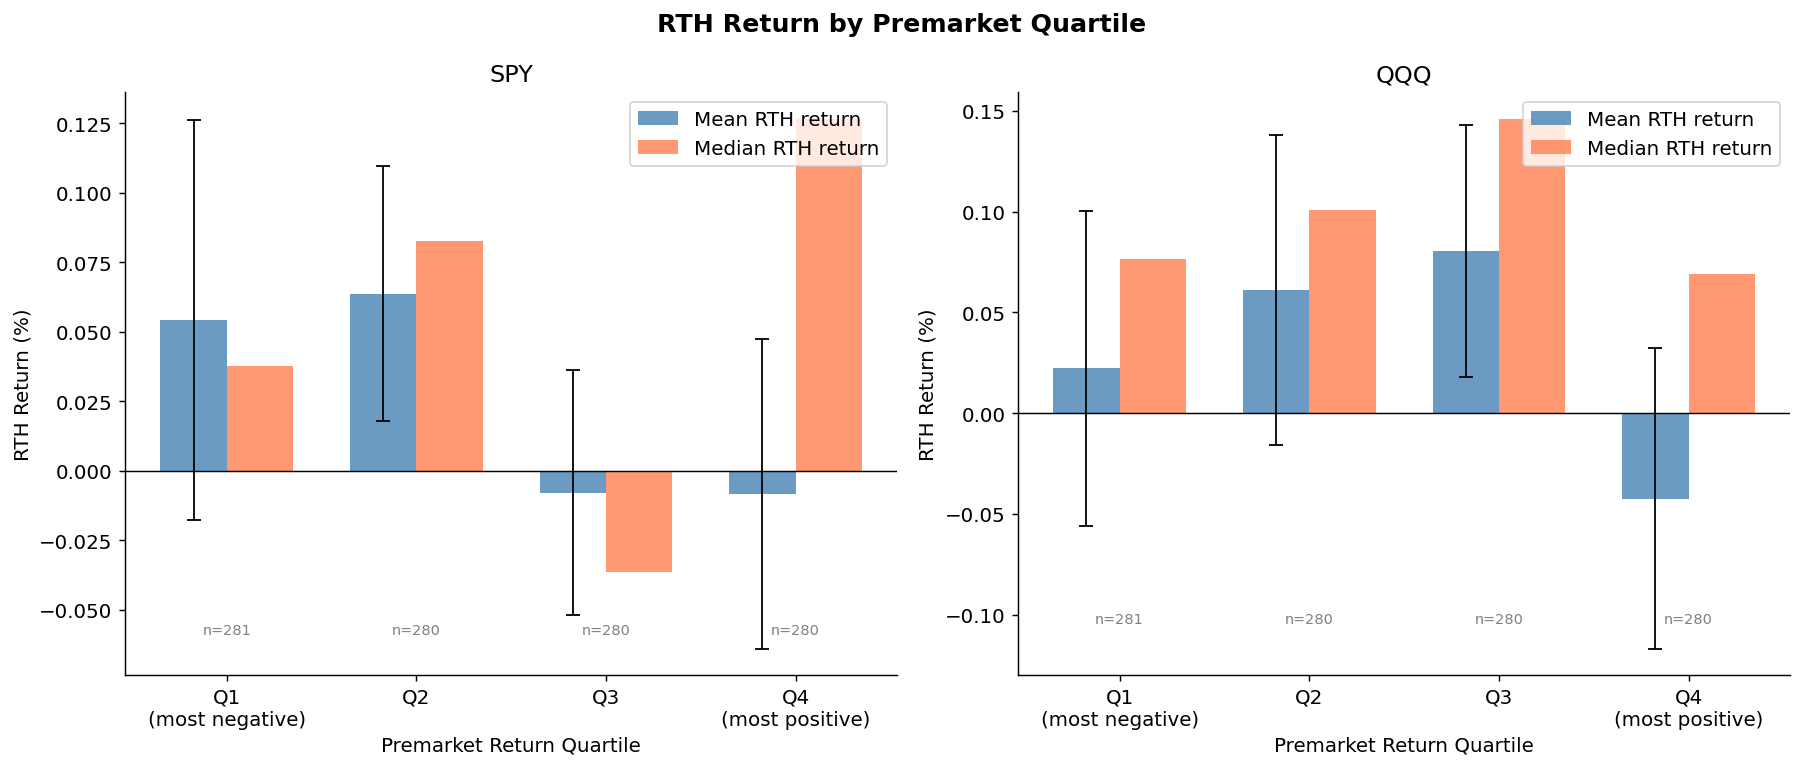


SPY — RTH return by premarket quartile
                  mean   median     std count
pm_quartile                                  
Q1 (most neg)   0.054%   0.038%  1.208%   281
Q2              0.064%   0.083%  0.769%   280
Q3             -0.008%  -0.036%  0.736%   280
Q4 (most pos)  -0.008%   0.127%  0.933%   280

QQQ — RTH return by premarket quartile
                  mean  median     std count
pm_quartile                                 
Q1 (most neg)   0.022%  0.077%  1.314%   281
Q2              0.061%  0.101%  1.287%   280
Q3              0.080%  0.146%  1.047%   280
Q4 (most pos)  -0.042%  0.069%  1.247%   280


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('RTH Return by Premarket Quartile', fontsize=14, fontweight='bold')

for ax, sym in zip(axes, SYMBOLS):
    df = data[sym].copy()
    df['pm_quartile'] = pd.qcut(
        df['premarket_return'],
        q=4,
        labels=['Q1\n(most negative)', 'Q2', 'Q3', 'Q4\n(most positive)']
    )

    summary = df.groupby('pm_quartile', observed=True)['rth_return'].agg(
        mean='mean', median='median', std='std', count='count'
    ).reset_index()
    summary['mean_pct'] = summary['mean'] * 100
    summary['median_pct'] = summary['median'] * 100
    summary['stderr'] = (summary['std'] / np.sqrt(summary['count'])) * 100

    x = np.arange(len(summary))
    width = 0.35

    bars_mean = ax.bar(x - width/2, summary['mean_pct'], width,
                       label='Mean RTH return', color='steelblue', alpha=0.8)
    bars_med = ax.bar(x + width/2, summary['median_pct'], width,
                      label='Median RTH return', color='coral', alpha=0.8)

    ax.errorbar(x - width/2, summary['mean_pct'], yerr=summary['stderr'],
                fmt='none', color='black', capsize=4, linewidth=1)

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(summary['pm_quartile'])
    ax.set_xlabel('Premarket Return Quartile')
    ax.set_ylabel('RTH Return (%)')
    ax.set_title(sym)
    ax.legend()

    for i, row in summary.iterrows():
        ax.text(i, ax.get_ylim()[0] * 0.8, f'n={int(row["count"])}',
                ha='center', fontsize=8, color='grey')

plt.tight_layout()
plt.show()

# Print table
for sym in SYMBOLS:
    df = data[sym].copy()
    df['pm_quartile'] = pd.qcut(df['premarket_return'], q=4,
                                 labels=['Q1 (most neg)', 'Q2', 'Q3', 'Q4 (most pos)'])
    tbl = df.groupby('pm_quartile', observed=True)['rth_return'].agg(
        ['mean', 'median', 'std', 'count']
    ).applymap(lambda x: f'{x*100:.3f}%' if abs(x) < 100 else str(int(x)))
    print(f'\n{sym} — RTH return by premarket quartile')
    print(tbl.to_string())

## 7. Rolling Correlation

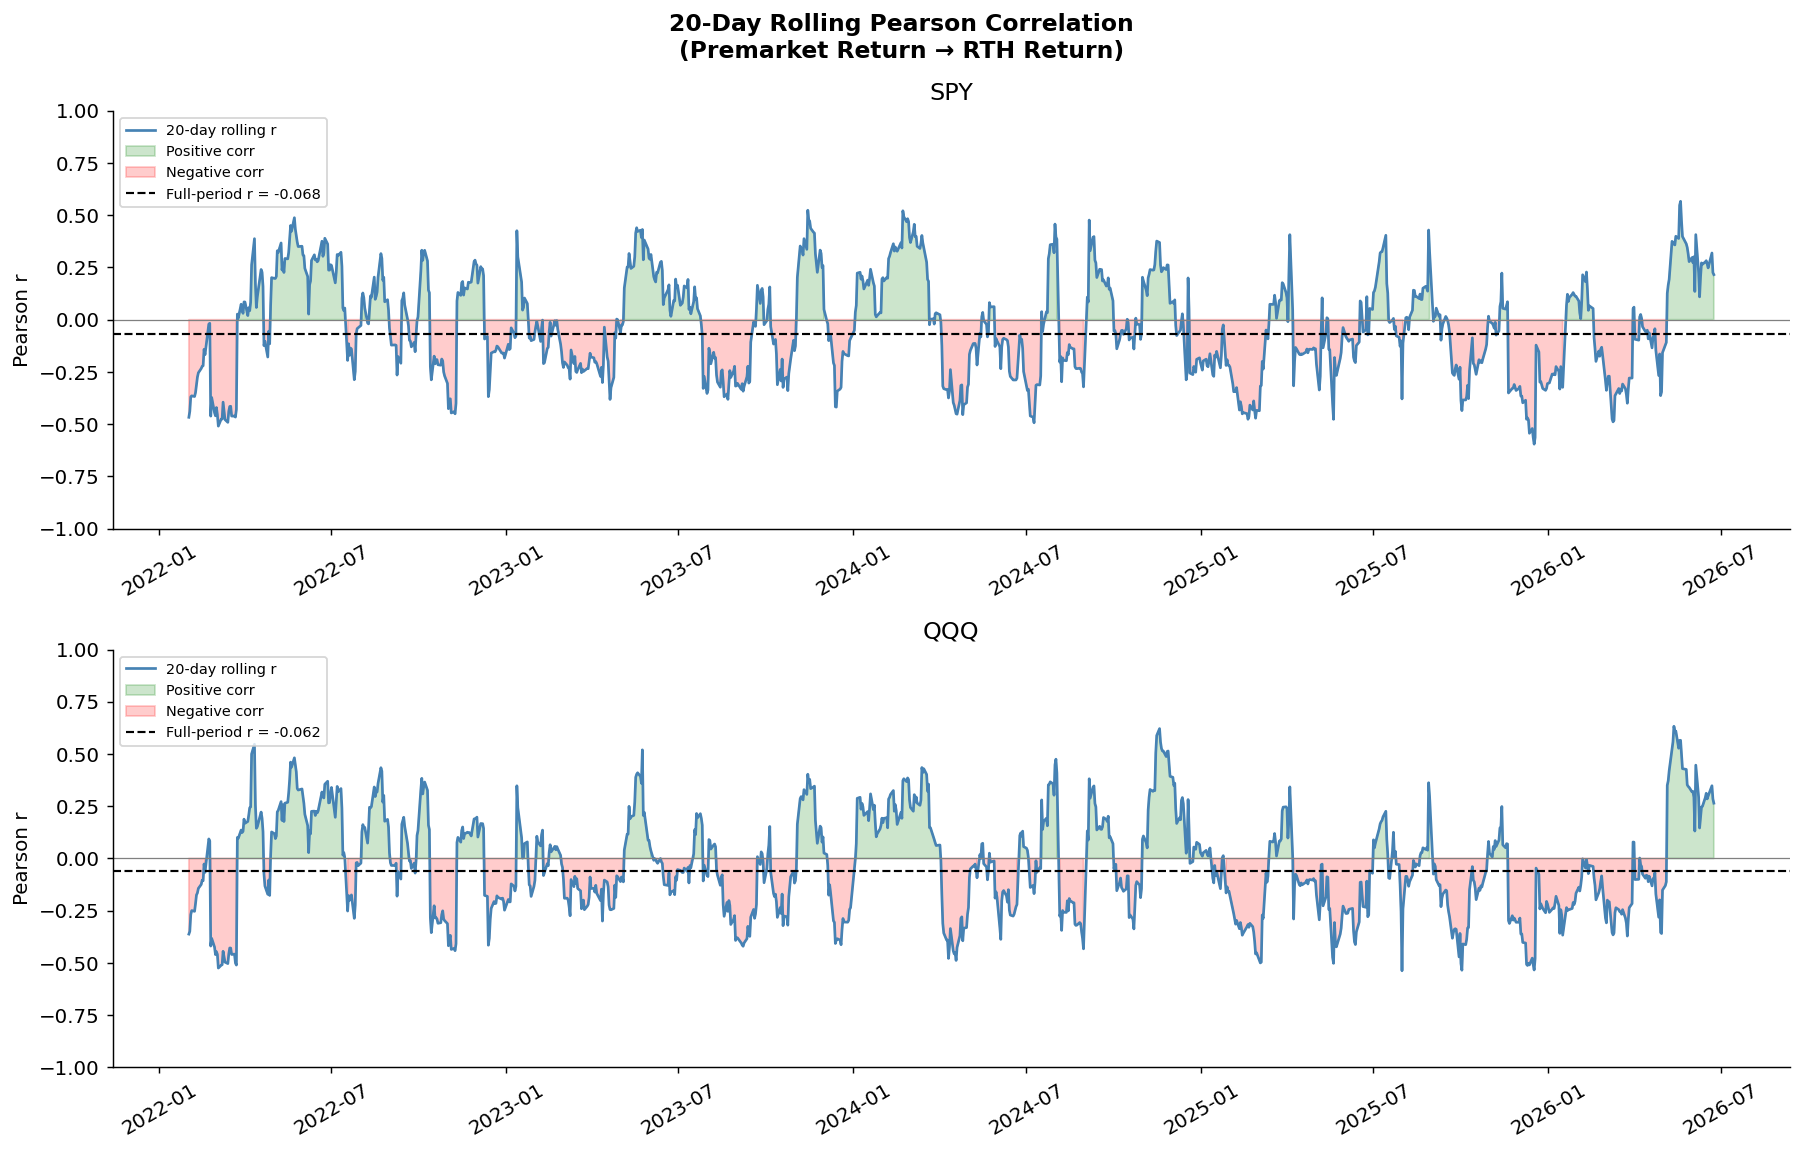

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)
fig.suptitle('20-Day Rolling Pearson Correlation\n(Premarket Return → RTH Return)',
             fontsize=13, fontweight='bold')

WINDOW = 20

for ax, sym in zip(axes, SYMBOLS):
    df = data[sym].copy()
    df['date_dt'] = pd.to_datetime(df['date'])

    rolling_corr = (
        df['premarket_return']
        .rolling(WINDOW)
        .corr(df['rth_return'])
    )

    ax.plot(df['date_dt'], rolling_corr, linewidth=1.5, color='steelblue', label=f'{WINDOW}-day rolling r')
    ax.fill_between(df['date_dt'], rolling_corr, 0,
                    where=(rolling_corr > 0), alpha=0.2, color='green', label='Positive corr')
    ax.fill_between(df['date_dt'], rolling_corr, 0,
                    where=(rolling_corr < 0), alpha=0.2, color='red', label='Negative corr')

    overall_r = corr_results[sym]['pearson_r']
    ax.axhline(overall_r, color='black', linestyle='--', linewidth=1.2,
               label=f'Full-period r = {overall_r:.3f}')
    ax.axhline(0, color='grey', linewidth=0.7)

    ax.set_title(sym)
    ax.set_ylabel('Pearson r')
    ax.set_ylim(-1, 1)
    ax.legend(fontsize=8, loc='upper left')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 8. SPY vs QQQ Side-by-Side Summary

In [10]:
rows = []
for sym in SYMBOLS:
    df = data[sym]
    pm = df['premarket_return']
    rth = df['rth_return']

    pearson_r, pearson_p = corr_results[sym]['pearson_r'], corr_results[sym]['pearson_p']
    spearman_r, spearman_p = corr_results[sym]['spearman_r'], corr_results[sym]['spearman_p']

    X = sm.add_constant(pm)
    ols = sm.OLS(rth, X).fit()

    dir_match = ((pm > 0) == (rth > 0)).mean()
    n = len(df)
    k = int(round(dir_match * n))
    binom_p = stats.binomtest(k, n, p=0.5).pvalue

    rows.append({
        'Symbol': sym,
        'N (days)': n,
        'Date range': f'{df["date"].min()} → {df["date"].max()}',
        'Pearson r': f'{pearson_r:+.4f}',
        'Pearson p': f'{pearson_p:.4f}',
        'Spearman ρ': f'{spearman_r:+.4f}',
        'OLS slope': f'{ols.params["premarket_return"]:.4f}',
        'OLS R²': f'{ols.rsquared:.4f}',
        'Dir. accuracy': f'{dir_match*100:.1f}%',
        'Dir. binom p': f'{binom_p:.4f}',
    })

summary_df = pd.DataFrame(rows).set_index('Symbol')
print('=== Full Summary ===')
print(summary_df.T.to_string())

=== Full Summary ===
Symbol                             SPY                      QQQ
N (days)                          1121                     1121
Date range     2022-01-04 → 2026-06-24  2022-01-04 → 2026-06-24
Pearson r                      -0.0679                  -0.0622
Pearson p                       0.0231                   0.0372
Spearman ρ                     -0.0108                  +0.0086
OLS slope                      -0.0934                  -0.0848
OLS R²                          0.0046                   0.0039
Dir. accuracy                    49.1%                    50.1%
Dir. binom p                    0.5503                   0.9524


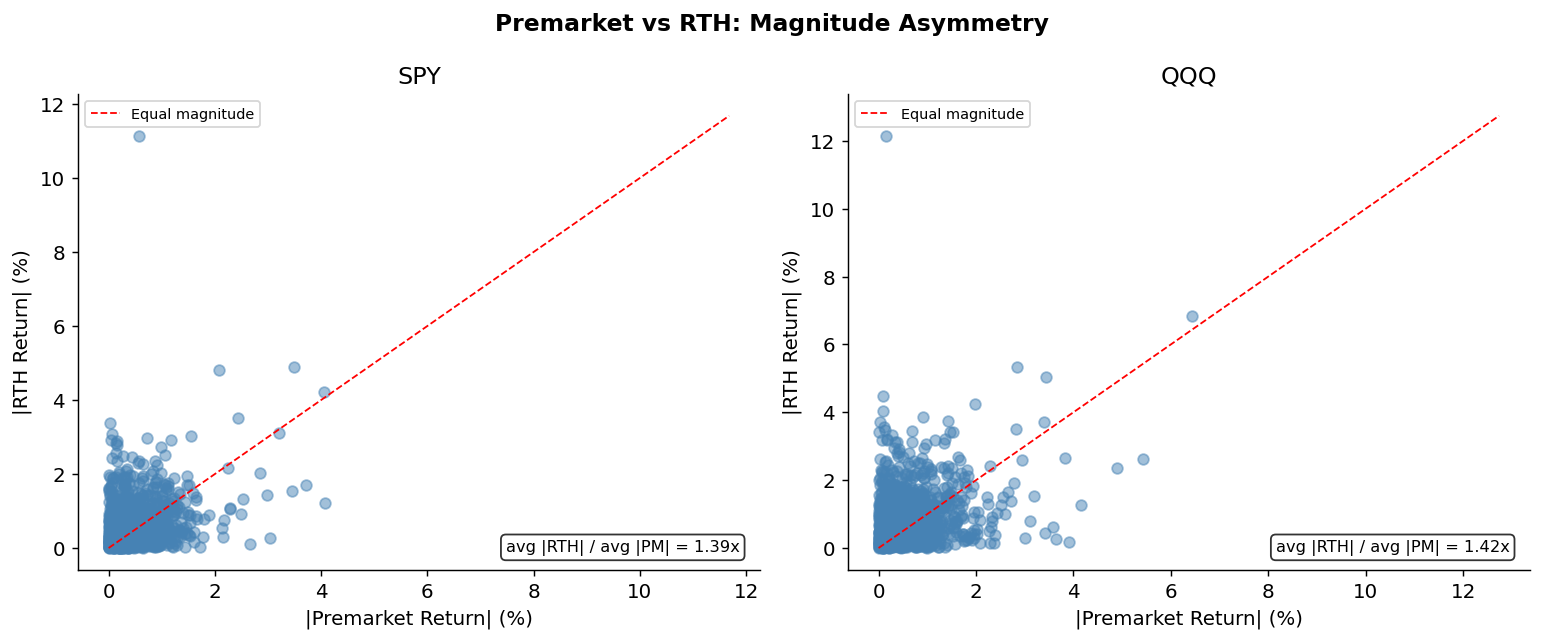

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Premarket vs RTH: Magnitude Asymmetry', fontsize=13, fontweight='bold')

for ax, sym in zip(axes, SYMBOLS):
    df = data[sym]

    pm_abs = df['premarket_return'].abs() * 100
    rth_abs = df['rth_return'].abs() * 100

    ax.scatter(pm_abs, rth_abs, alpha=0.5, s=35, color='steelblue')

    # y = x reference line (equal magnitude)
    lim = max(pm_abs.max(), rth_abs.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1, label='Equal magnitude')

    ax.set_xlabel('|Premarket Return| (%)')
    ax.set_ylabel('|RTH Return| (%)')
    ax.set_title(sym)
    ax.legend(fontsize=8)

    ratio = rth_abs.mean() / pm_abs.mean()
    ax.text(0.97, 0.03,
            f'avg |RTH| / avg |PM| = {ratio:.2f}x',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

## 10. Window Analysis: Last 30 Min Pre-Market vs First 30 Min RTH

The full premarket session spans 4:00–9:30 ET across ~5.5 hours of often thin, noisy trading.
The **last 30 minutes** (9:00–9:30 ET) is when institutional order flow concentrates and price
discovery is most meaningful. Does this narrower window predict RTH better than the full session?

We also look at whether premarket predicts the **first 30 minutes of RTH** (9:30–10:00 ET)
separately from the **rest of RTH** (10:00–16:00 ET), since the opening period behaves differently.

In [12]:
window_cols = ['last30_pre_return', 'first30_rth_return', 'rest_rth_return']

# Verify window columns exist and have data
for sym in SYMBOLS:
    df = data[sym]
    available = [c for c in window_cols if c in df.columns and df[c].notna().any()]
    missing = [c for c in window_cols if c not in available]
    print(f'{sym}: window columns available={available}')
    if missing:
        print(f'  Missing (daily-res data, re-run fetch_bars.py): {missing}')
    else:
        print(f'  last30_pre  — mean={df["last30_pre_return"].mean()*100:+.3f}%  std={df["last30_pre_return"].std()*100:.3f}%')
        print(f'  first30_rth — mean={df["first30_rth_return"].mean()*100:+.3f}%  std={df["first30_rth_return"].std()*100:.3f}%')
        print(f'  rest_rth    — mean={df["rest_rth_return"].mean()*100:+.3f}%  std={df["rest_rth_return"].std()*100:.3f}%')
    print()

SPY: window columns available=['last30_pre_return', 'first30_rth_return', 'rest_rth_return']
  last30_pre  — mean=+0.020%  std=0.675%
  first30_rth — mean=+0.009%  std=0.303%
  rest_rth    — mean=+0.015%  std=0.864%

QQQ: window columns available=['last30_pre_return', 'first30_rth_return', 'rest_rth_return']
  last30_pre  — mean=+0.035%  std=0.900%
  first30_rth — mean=+0.010%  std=0.474%
  rest_rth    — mean=+0.019%  std=1.092%



In [13]:
print('=== Correlations: Window-Level Predictive Power ===\n')
print(f'{"Predictor":<22} {"Target":<22} {"Symbol":>6}  {"r":>8}  {"p":>8}  {"sig":>5}')
print('-' * 75)

pairs = [
    ('premarket_return',   'rth_return',          'Full PRE  → Full RTH'),
    ('last30_pre_return',  'rth_return',           'Last30PRE → Full RTH'),
    ('last30_pre_return',  'first30_rth_return',   'Last30PRE → First30RTH'),
    ('last30_pre_return',  'rest_rth_return',      'Last30PRE → RestRTH'),
    ('premarket_return',   'first30_rth_return',   'Full PRE  → First30RTH'),
    ('premarket_return',   'rest_rth_return',      'Full PRE  → RestRTH'),
]

window_results = {}
for sym in SYMBOLS:
    df = data[sym].dropna(subset=window_cols)
    window_results[sym] = {}
    for pred, target, label in pairs:
        if pred not in df.columns or target not in df.columns:
            continue
        valid = df[[pred, target]].dropna()
        if len(valid) < 5:
            continue
        r, p = stats.pearsonr(valid[pred], valid[target])
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
        window_results[sym][label] = {'r': r, 'p': p, 'n': len(valid)}
        print(f'{label:<40} {sym:>6}  {r:+8.4f}  {p:8.4f}  {sig:>5}')
    print()

=== Correlations: Window-Level Predictive Power ===

Predictor              Target                 Symbol         r         p    sig
---------------------------------------------------------------------------
Full PRE  → Full RTH                        SPY   -0.0671    0.0247      *
Last30PRE → Full RTH                        SPY   -0.0671    0.0247      *
Last30PRE → First30RTH                      SPY   -0.0191    0.5237   n.s.
Last30PRE → RestRTH                         SPY   -0.0664    0.0262      *
Full PRE  → First30RTH                      SPY   -0.0191    0.5237   n.s.
Full PRE  → RestRTH                         SPY   -0.0664    0.0262      *

Full PRE  → Full RTH                        QQQ   -0.0621    0.0378      *
Last30PRE → Full RTH                        QQQ   -0.0621    0.0378      *
Last30PRE → First30RTH                      QQQ   -0.0808    0.0068     **
Last30PRE → RestRTH                         QQQ   -0.0356    0.2338   n.s.
Full PRE  → First30RTH                  

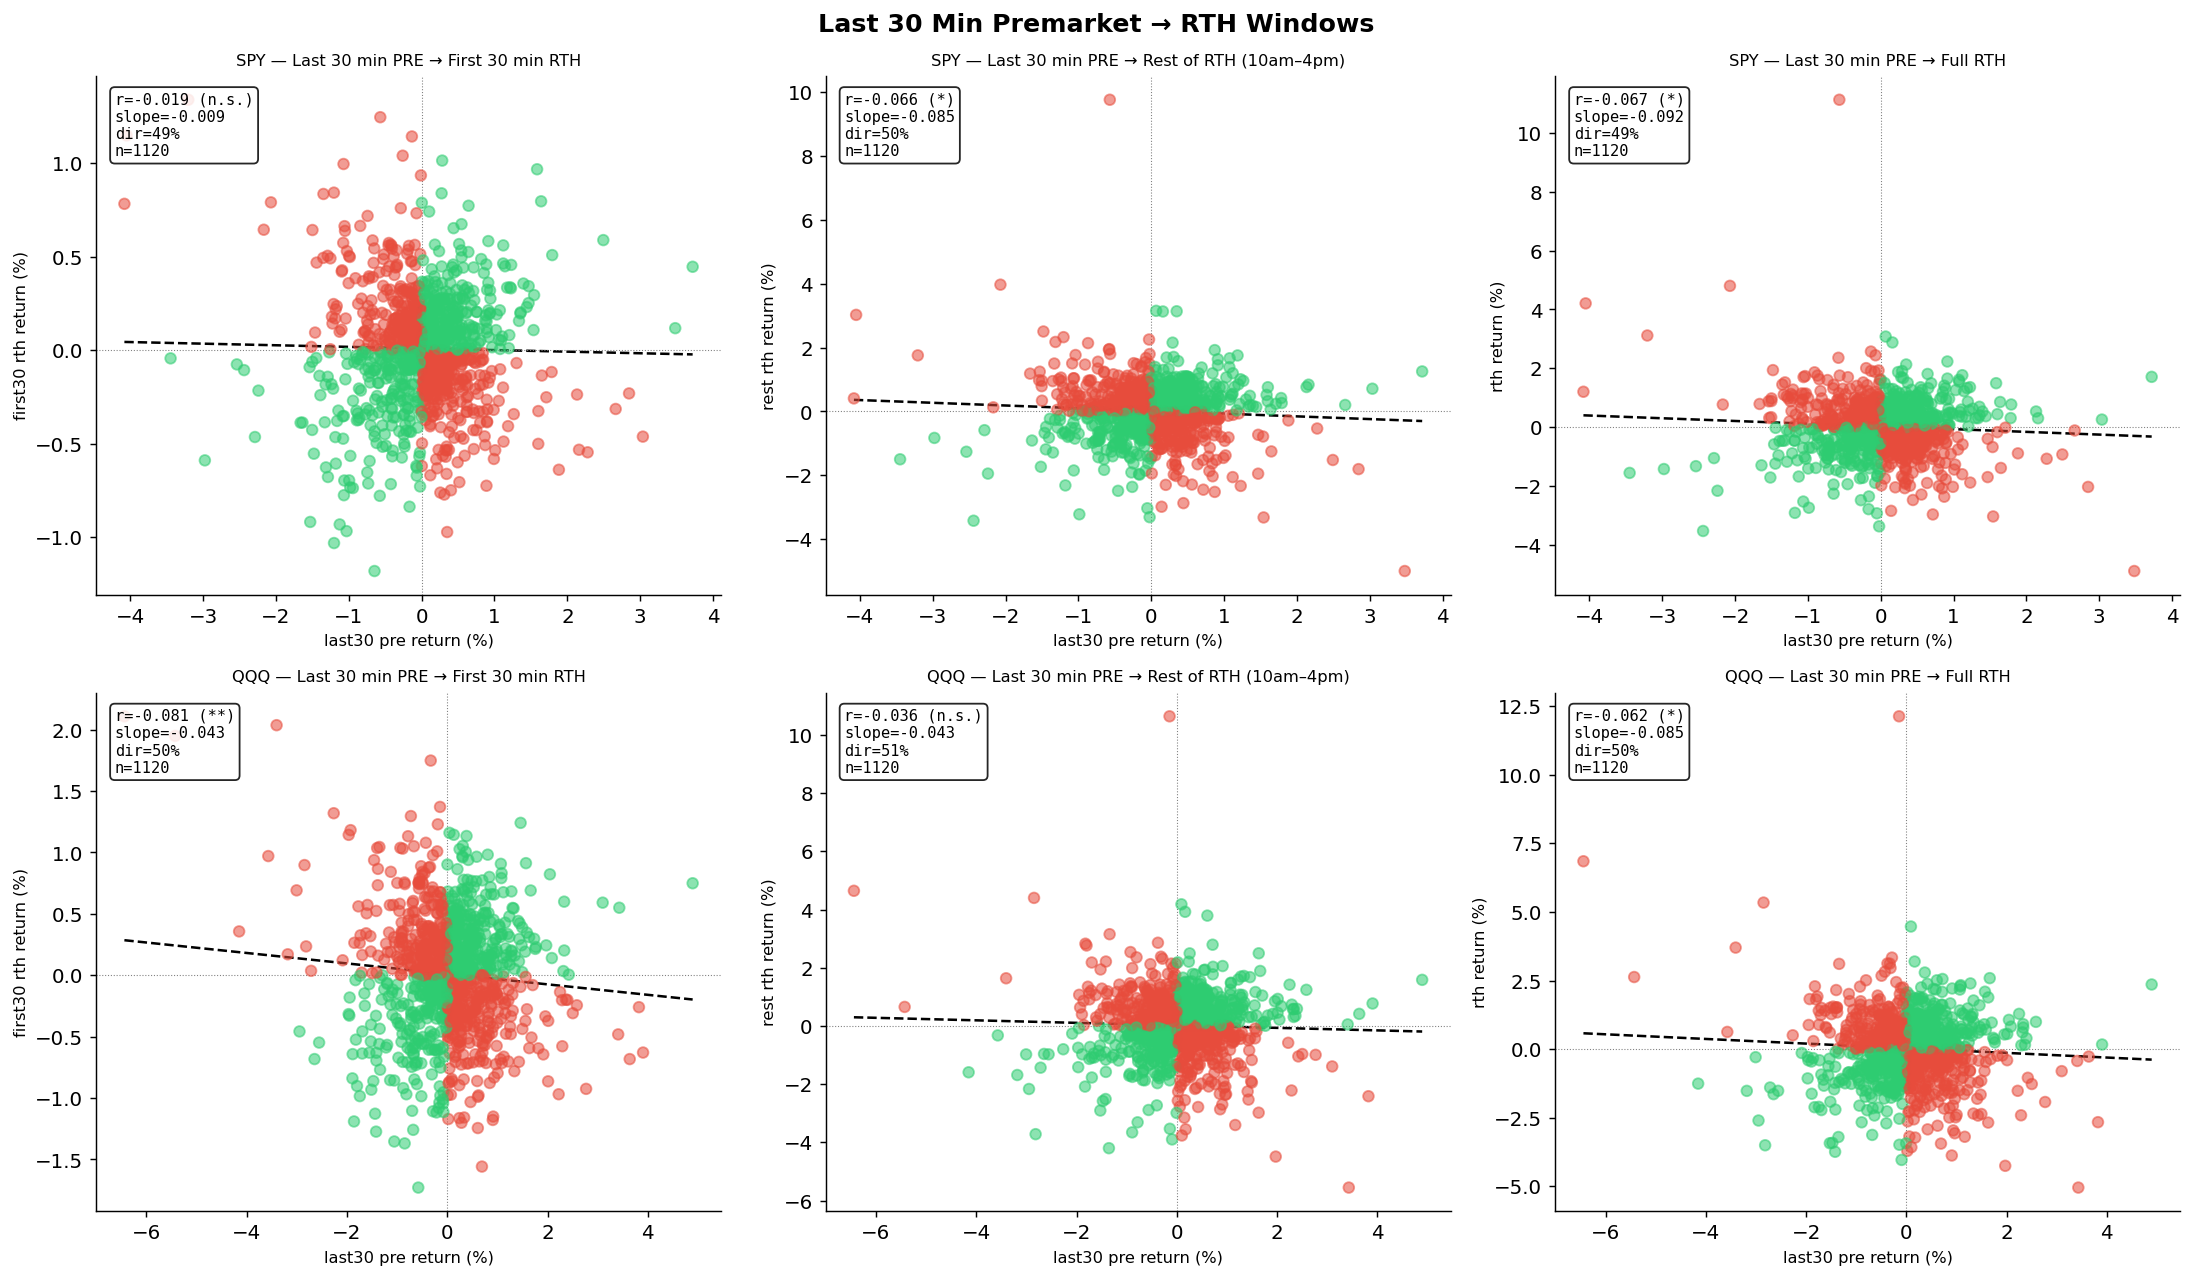

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Last 30 Min Premarket → RTH Windows', fontsize=14, fontweight='bold')

plot_pairs = [
    ('last30_pre_return', 'first30_rth_return', 'Last 30 min PRE → First 30 min RTH'),
    ('last30_pre_return', 'rest_rth_return',    'Last 30 min PRE → Rest of RTH (10am–4pm)'),
    ('last30_pre_return', 'rth_return',          'Last 30 min PRE → Full RTH'),
]

for row, sym in enumerate(SYMBOLS):
    df = data[sym].dropna(subset=window_cols)
    for col, (pred, target, title) in enumerate(plot_pairs):
        ax = axes[row, col]
        valid = df[[pred, target]].dropna()
        x = valid[pred] * 100
        y = valid[target] * 100

        colors = ['#2ecc71' if (xi > 0) == (yi > 0) else '#e74c3c' for xi, yi in zip(x, y)]
        ax.scatter(x, y, c=colors, alpha=0.55, s=35, zorder=3)

        m, b, r_val, p_val, _ = stats.linregress(x, y)
        x_range = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_range, m * x_range + b, 'k--', linewidth=1.4)
        ax.axhline(0, color='grey', linewidth=0.6, linestyle=':')
        ax.axvline(0, color='grey', linewidth=0.6, linestyle=':')

        dir_match = sum((xi > 0) == (yi > 0) for xi, yi in zip(x, y)) / len(x) * 100
        sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'n.s.'))
        info = f'r={r_val:+.3f} ({sig})\nslope={m:.3f}\ndir={dir_match:.0f}%\nn={len(valid)}'
        ax.text(0.03, 0.97, info, transform=ax.transAxes, ha='left', va='top',
                fontsize=8.5, fontfamily='monospace',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

        ax.set_xlabel(pred.replace('_', ' ') + ' (%)', fontsize=9)
        ax.set_ylabel(target.replace('_', ' ') + ' (%)', fontsize=9)
        ax.set_title(f'{sym} — {title}', fontsize=9)

plt.tight_layout()
plt.show()

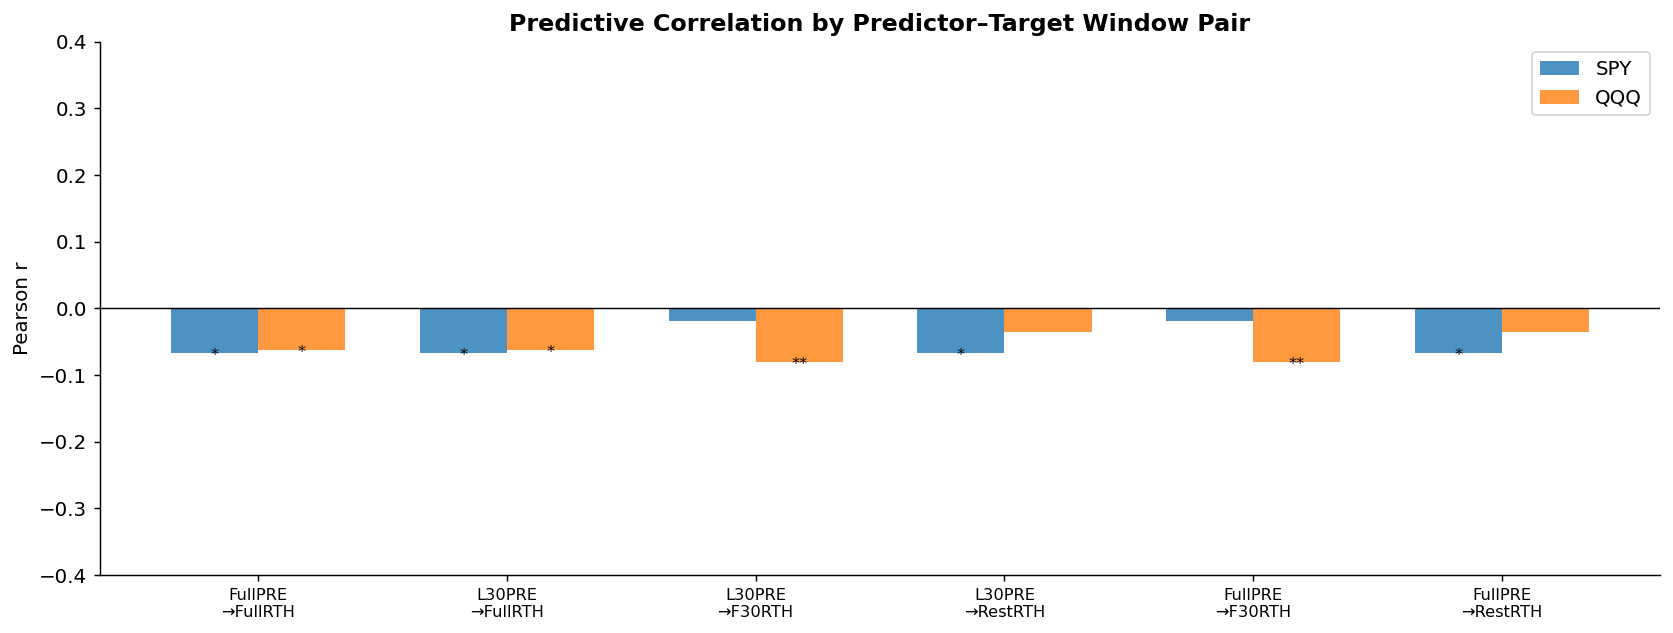

In [15]:
# Bar chart: compare r values across all predictor→target pairs for both symbols
labels = [p[2].replace('Full PRE', 'FullPRE').replace('Last30PRE', 'L30PRE')
          .replace('Full RTH', 'FullRTH').replace('First30RTH', 'F30RTH')
          .replace('RestRTH', 'RestRTH')
          for p in pairs]

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(pairs))
width = 0.35

for i, sym in enumerate(SYMBOLS):
    r_vals = [window_results[sym].get(p[2], {}).get('r', 0) for p in pairs]
    p_vals = [window_results[sym].get(p[2], {}).get('p', 1) for p in pairs]
    bars = ax.bar(x + i * width, r_vals, width, label=sym, alpha=0.8)
    for bar, r, p_val in zip(bars, r_vals, p_vals):
        sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else ''))
        if sig:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    r + (0.005 if r >= 0 else -0.015),
                    sig, ha='center', va='bottom', fontsize=9)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + width / 2)
short_labels = [
    'FullPRE\n→FullRTH',
    'L30PRE\n→FullRTH',
    'L30PRE\n→F30RTH',
    'L30PRE\n→RestRTH',
    'FullPRE\n→F30RTH',
    'FullPRE\n→RestRTH',
]
ax.set_xticklabels(short_labels, fontsize=9)
ax.set_ylabel('Pearson r')
ax.set_title('Predictive Correlation by Predictor–Target Window Pair', fontweight='bold')
ax.legend()
ax.set_ylim(-0.4, 0.4)
plt.tight_layout()
plt.show()

## 9. Interpretation Guide

| Metric | Interpretation |
|--------|----------------|
| **Pearson r** | Linear correlation strength. +1 = perfect follow-through, 0 = no predictive power, −1 = perfect reversal. |
| **p-value** | Probability of observing this r by chance if the true r = 0. < 0.05 = statistically significant. |
| **OLS slope** | For every 1% premarket move, RTH is expected to move `slope`%. > 1 = amplification, < 1 = dampening. |
| **OLS R²** | Fraction of RTH variance explained by premarket. Even statistically significant correlations often have low R². |
| **Directional accuracy** | What % of the time did premarket direction correctly predict RTH direction? 50% = coin flip. |
| **Binomial p** | Tests whether directional accuracy is significantly different from the 50% baseline. |
| **Rolling r** | Stability check — a correlation that flip-flops may not be practically useful even if significant overall. |

### Caveats
- Results cover only the last ~3–4 months (Webull API limit of 1200 bars at M30 resolution).
- Both SPY and QQQ respond to the same macro drivers, so their results will be highly correlated with each other.
- Statistical significance ≠ economic significance. A significant but tiny R² means premarket explains very little of the day-to-day RTH variance.
- No transaction costs, slippage, or market-impact are modelled here.